In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [15]:
dataset = pd.read_excel("/content/melb_data.xlsx")

In [16]:
dataset.head(3)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,2016-12-03,2.5,3067.0,...,1,1.0,202.0,NaN,NaN,Yarra,NaN,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2016-02-04,2.5,3067.0,...,1,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,2017-03-04,2.5,3067.0,...,2,0.0,134.0,150.0,1900.0,NaN,-37.8093,NaN,Northern Metropolitan,4019.0


In [4]:
dataset.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,138


/tmp/ipython-input-474668104.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Propertycount"])


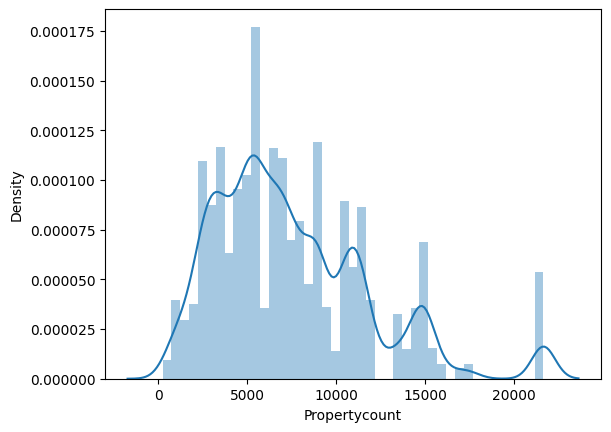

In [17]:
 sns.distplot(dataset["Propertycount"])
 plt.show()

In [29]:
q1 = dataset["Propertycount"].quantile(0.25)
q3 = dataset["Propertycount"].quantile(0.75)
iqr = q3 - q1

In [7]:
min_r = q1-(1.5*iqr)
max_r = q3+(1.5*iqr)
min_r,max_r

(np.float64(-4546.5), np.float64(19257.5))

In [8]:
# dataset = dataset[dataset["Propertycount"]<=max_r]

In [23]:
from sklearn.preprocessing import FunctionTransformer

In [24]:
ft = FunctionTransformer(func=np.log1p)
ft.fit(dataset[["Propertycount"]])

FunctionTransformer(func=<ufunc 'log1p'>)

In [25]:
dataset["Propertycount_tf"] = ft.transform(dataset[["Propertycount"]])

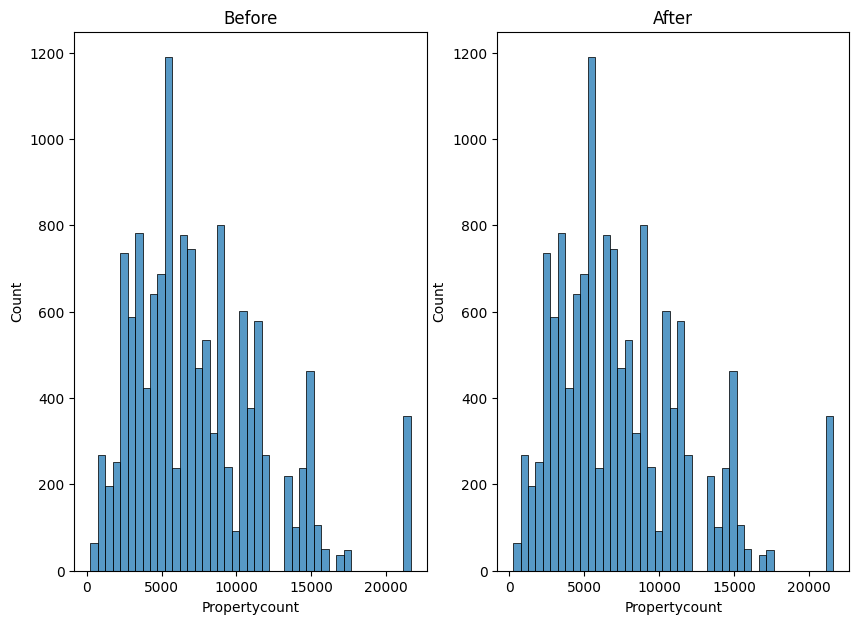

In [26]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
sns.histplot(dataset["Propertycount"])
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(dataset["Propertycount"])
plt.title("After")
plt.show()

In [27]:
ft1 = FunctionTransformer(func= lambda x : x**2)
ft1.fit(dataset[["Propertycount"]])
dataset["Propertycount"] = ft1.transform(dataset[["Propertycount"]])

<Figure size 1000x400 with 0 Axes>

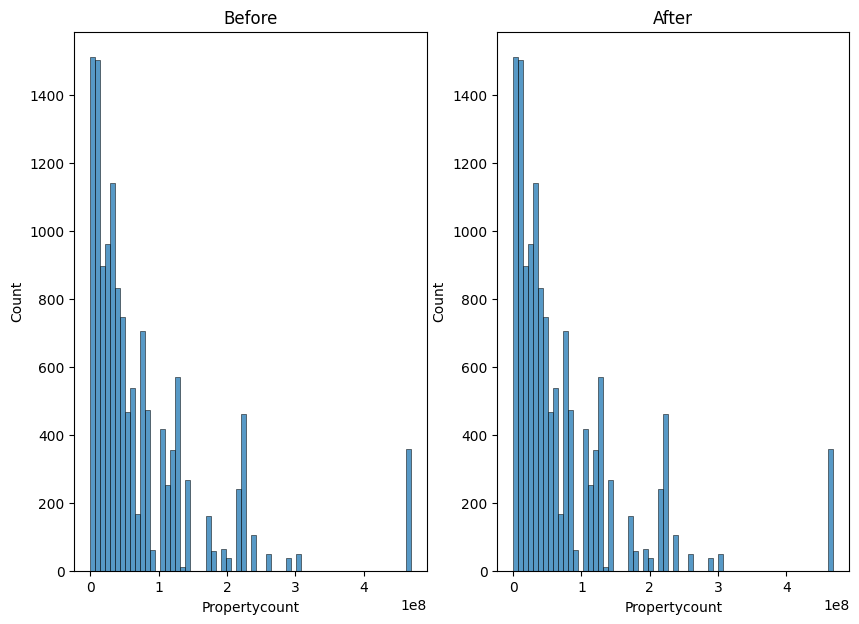

In [28]:
plt.figure(figsize=(10,4))
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
sns.histplot(dataset["Propertycount"])
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(dataset["Propertycount"])
plt.title("After")
plt.show()